# Disease Prediction Using Machine Learning
## Bernoulli Naive Bayes and Decision Tree

## Table of Contents

- [Phase 1 — Data Exploration & Preparation](#phase-1--data-exploration--preparation)
  - [1.1 — Load and Inspect the Data](#phase-11--load-and-inspect-the-data)
  - [1.2 — Exploratory Data Analysis (EDA)](#phase-12--exploratory-data-analysis-eda)
  - [1.3 — Deeper Data Analysis](#phase-13--deeper-data-analysis)
    - [EDA Summary](#eda-summary-phases-11--13)
  - [1.4 — Preprocessing](#phase-14--preprocessing)
- [Phase 2 — Model Development](#phase-21--bernoulli-naive-bayes-model)
  - [2.1 — Bernoulli Naive Bayes Model](#phase-21--bernoulli-naive-bayes-model)
  - [2.2 — Decision Tree Model](#phase-22--decision-tree-model)
- [Phase 3 — Model Comparison](#phase-3--model-comparison)
- [Project Summary](#project-summary)

---
## Phase 1 — Data Exploration & Preparation
### Phase 1.1 — Load and Inspect the Data

In [26]:
import pandas as pd
import numpy as np

# Load datasets
train_df = pd.read_csv("../data/raw/Training.csv")
test_df = pd.read_csv("../data/raw/Testing.csv")

print("=== Training Data ===")
print(f"Shape: {train_df.shape}")
print(f"\nColumn types:\n{train_df.dtypes.value_counts()}")
print(f"\nFirst 5 rows:")
train_df.head()

=== Training Data ===
Shape: (4920, 133)

Column types:
int64    132
str        1
Name: count, dtype: int64

First 5 rows:


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


### Phase 1.2 — Exploratory Data Analysis (EDA)

In [27]:
# Basic summary statistics
print("=== Missing Values (Training) ===")
print(train_df.isnull().sum().sum(), "total missing values")

print("\n=== Missing Values (Testing) ===")
print(test_df.isnull().sum().sum(), "total missing values")

print("\n=== Unique diseases (Training) ===")
print(f"{train_df['prognosis'].nunique()} classes")
print(train_df['prognosis'].unique())

=== Missing Values (Training) ===
0 total missing values

=== Missing Values (Testing) ===
0 total missing values

=== Unique diseases (Training) ===
41 classes
<ArrowStringArray>
[                       'Fungal infection',
                                 'Allergy',
                                    'GERD',
                     'Chronic cholestasis',
                           'Drug Reaction',
                     'Peptic ulcer diseae',
                                    'AIDS',
                               'Diabetes ',
                         'Gastroenteritis',
                        'Bronchial Asthma',
                           'Hypertension ',
                                'Migraine',
                    'Cervical spondylosis',
            'Paralysis (brain hemorrhage)',
                                'Jaundice',
                                 'Malaria',
                             'Chicken pox',
                                  'Dengue',
                            

C:\Users\hmwan\AppData\Local\Temp\ipykernel_28136\3211068900.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disease_counts.values, y=disease_counts.index, palette="viridis")


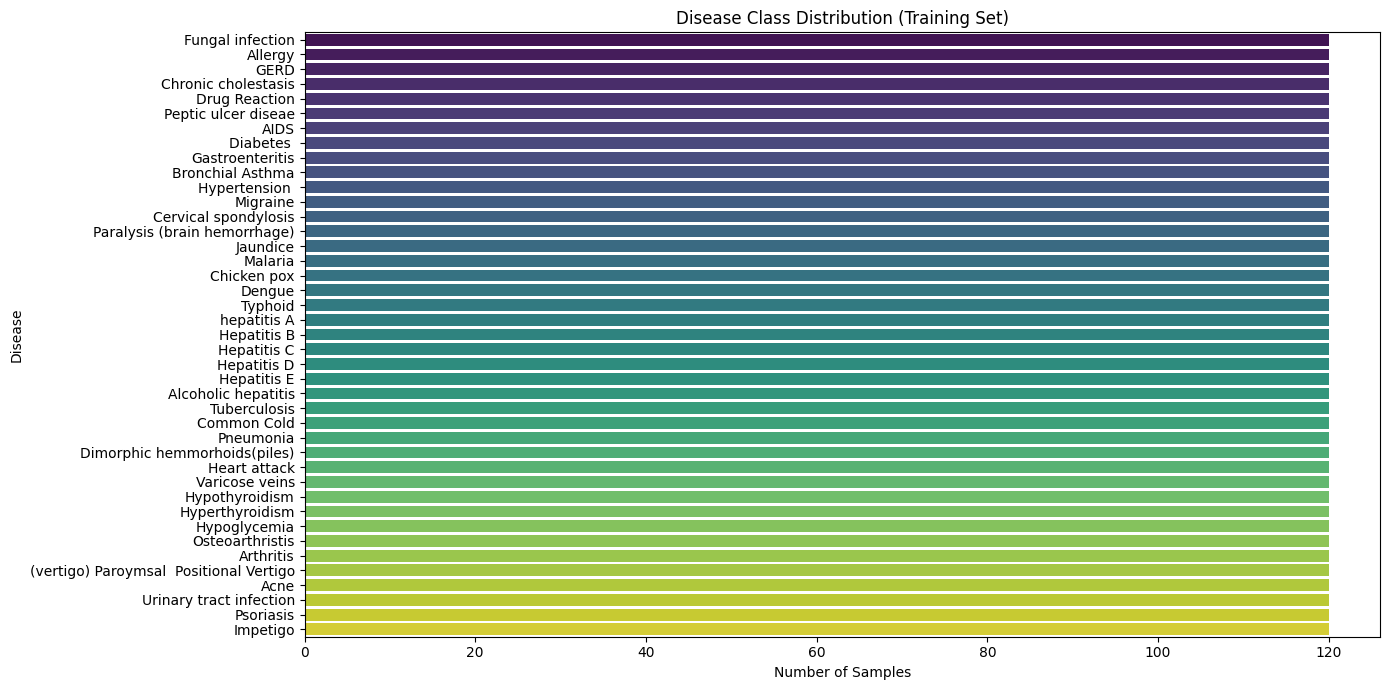


Samples per class — min: 120, max: 120, mean: 120.0


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class distribution — disease frequency
disease_counts = train_df['prognosis'].value_counts()

plt.figure(figsize=(14, 7))
sns.barplot(x=disease_counts.values, y=disease_counts.index, palette="viridis")
plt.title("Disease Class Distribution (Training Set)")
plt.xlabel("Number of Samples")
plt.ylabel("Disease")
plt.tight_layout()
plt.show()

print(f"\nSamples per class — min: {disease_counts.min()}, max: {disease_counts.max()}, mean: {disease_counts.mean():.1f}")

C:\Users\hmwan\AppData\Local\Temp\ipykernel_28136\3627244351.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=symptom_freq.head(20).values, y=symptom_freq.head(20).index, palette="magma")


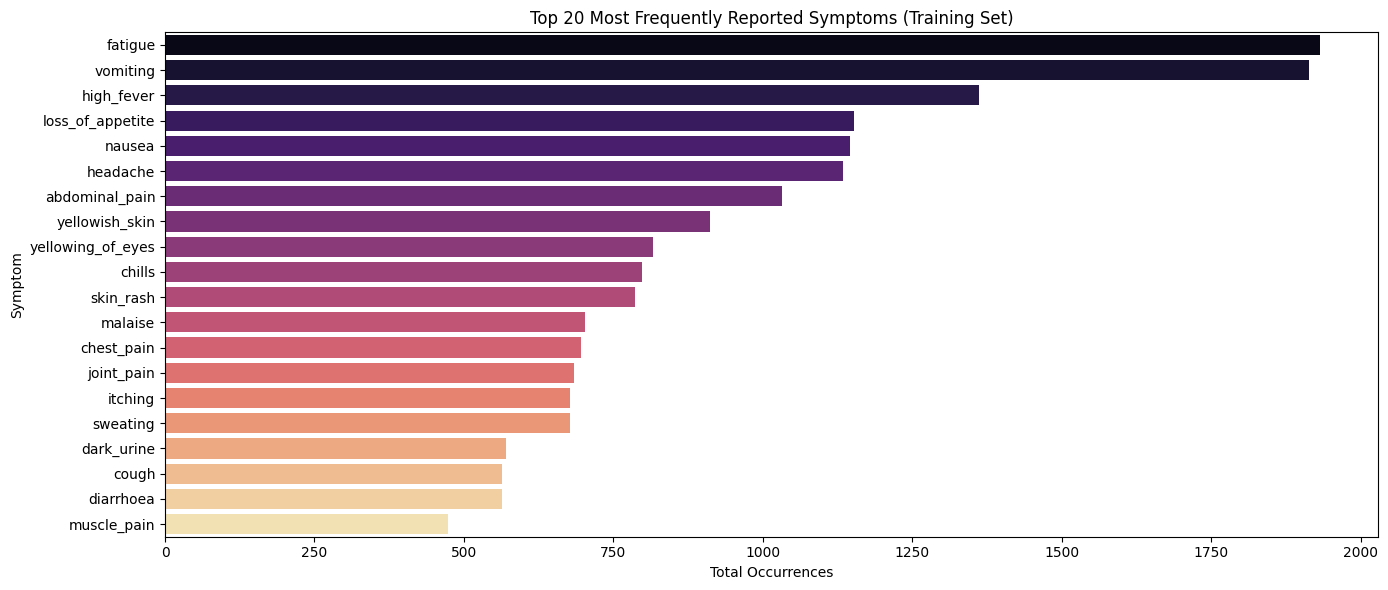


Total symptom columns: 132
Symptoms with zero occurrences: 1


In [29]:
# Top 20 most common symptoms across all training samples
symptom_cols = [c for c in train_df.columns if c != 'prognosis']
symptom_freq = train_df[symptom_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=symptom_freq.head(20).values, y=symptom_freq.head(20).index, palette="magma")
plt.title("Top 20 Most Frequently Reported Symptoms (Training Set)")
plt.xlabel("Total Occurrences")
plt.ylabel("Symptom")
plt.tight_layout()
plt.show()

print(f"\nTotal symptom columns: {len(symptom_cols)}")
print(f"Symptoms with zero occurrences: {(symptom_freq == 0).sum()}")

### Phase 1.3 — Deeper Data Analysis

In [30]:
# ── 1. Duplicate rows & train/test class consistency ──────────────────────────
print("=== Duplicate Rows ===")
print(f"Training duplicates : {train_df.duplicated().sum()}")
print(f"Testing  duplicates : {test_df.duplicated().sum()}")

train_classes = set(train_df['prognosis'].unique())
test_classes  = set(test_df['prognosis'].unique())

print("\n=== Train / Test Class Consistency ===")
print(f"Classes in train only : {train_classes - test_classes}")
print(f"Classes in test  only : {test_classes  - train_classes}")
print(f"Shared classes        : {len(train_classes & test_classes)} / {len(train_classes)}")

=== Duplicate Rows ===
Training duplicates : 4616
Testing  duplicates : 0

=== Train / Test Class Consistency ===
Classes in train only : set()
Classes in test  only : set()
Shared classes        : 41 / 41


Zero-variance symptoms  : 1
Near-zero-variance (<0.01): 1

Bottom 10 lowest-variance symptoms:
fluid_overload          0.000000
foul_smell_of urine     0.020306
muscle_wasting          0.021474
nodal_skin_eruptions    0.021474
spotting_ urination     0.021474
dehydration             0.021474
sunken_eyes             0.021474
shivering               0.021474
weakness_in_limbs       0.021474
patches_in_throat       0.021474


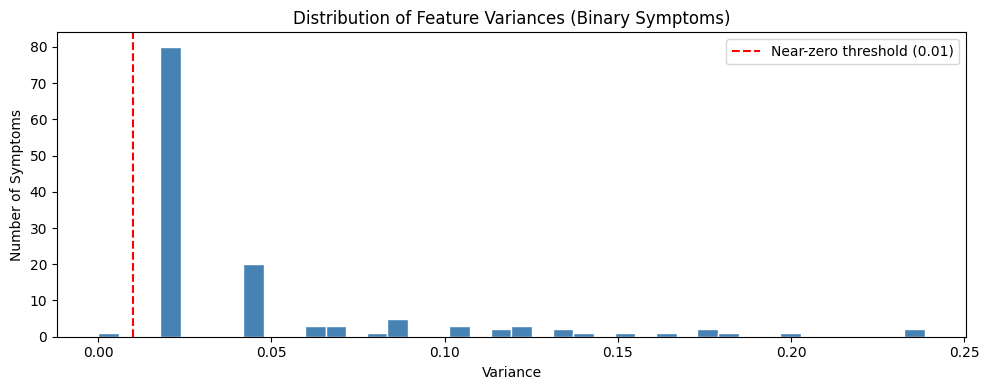

In [31]:
# ── 2. Feature variance analysis ──────────────────────────────────────────────
# For binary features, variance = p*(1-p). Low variance → near-constant feature.
feature_var = train_df[symptom_cols].var().sort_values()

zero_var     = (feature_var == 0).sum()
near_zero    = (feature_var < 0.01).sum()   # threshold: <1% variance

print(f"Zero-variance symptoms  : {zero_var}")
print(f"Near-zero-variance (<0.01): {near_zero}")
print(f"\nBottom 10 lowest-variance symptoms:")
print(feature_var.head(10).to_string())

plt.figure(figsize=(10, 4))
plt.hist(feature_var.values, bins=40, color="steelblue", edgecolor="white")
plt.axvline(0.01, color="red", linestyle="--", label="Near-zero threshold (0.01)")
plt.title("Distribution of Feature Variances (Binary Symptoms)")
plt.xlabel("Variance")
plt.ylabel("Number of Symptoms")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\hmwan\AppData\Local\Temp\ipykernel_28136\2593712551.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_symptoms.values, y=avg_symptoms.index, palette="coolwarm")


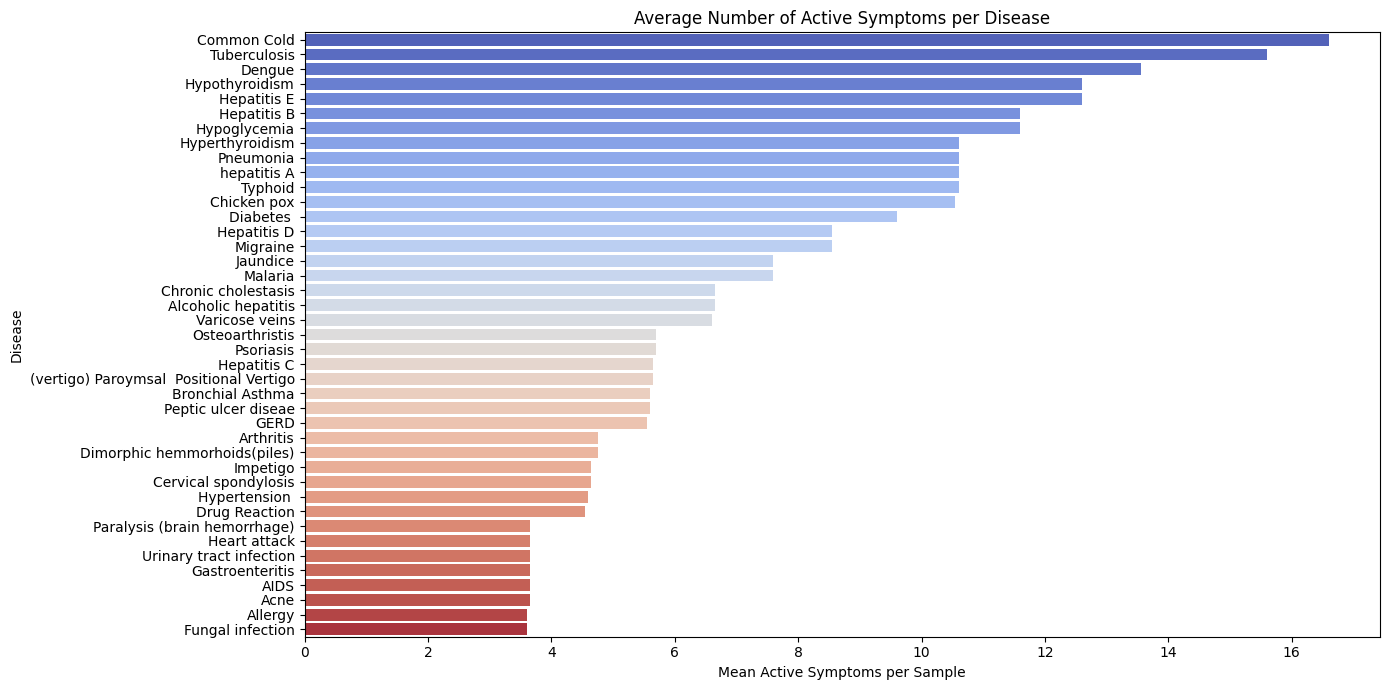


Most symptom-rich disease : Common Cold (16.6 avg symptoms)
Least symptom-rich disease: Allergy (3.6 avg symptoms)


In [32]:
# ── 3. Average number of active symptoms per disease ──────────────────────────
avg_symptoms = (
    train_df.groupby('prognosis')[symptom_cols]
    .mean()               # mean of 0/1 = proportion of samples with that symptom
    .sum(axis=1)          # total "expected" active symptoms per disease
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 7))
sns.barplot(x=avg_symptoms.values, y=avg_symptoms.index, palette="coolwarm")
plt.title("Average Number of Active Symptoms per Disease")
plt.xlabel("Mean Active Symptoms per Sample")
plt.ylabel("Disease")
plt.tight_layout()
plt.show()

print(f"\nMost symptom-rich disease : {avg_symptoms.idxmax()} ({avg_symptoms.max():.1f} avg symptoms)")
print(f"Least symptom-rich disease: {avg_symptoms.idxmin()} ({avg_symptoms.min():.1f} avg symptoms)")

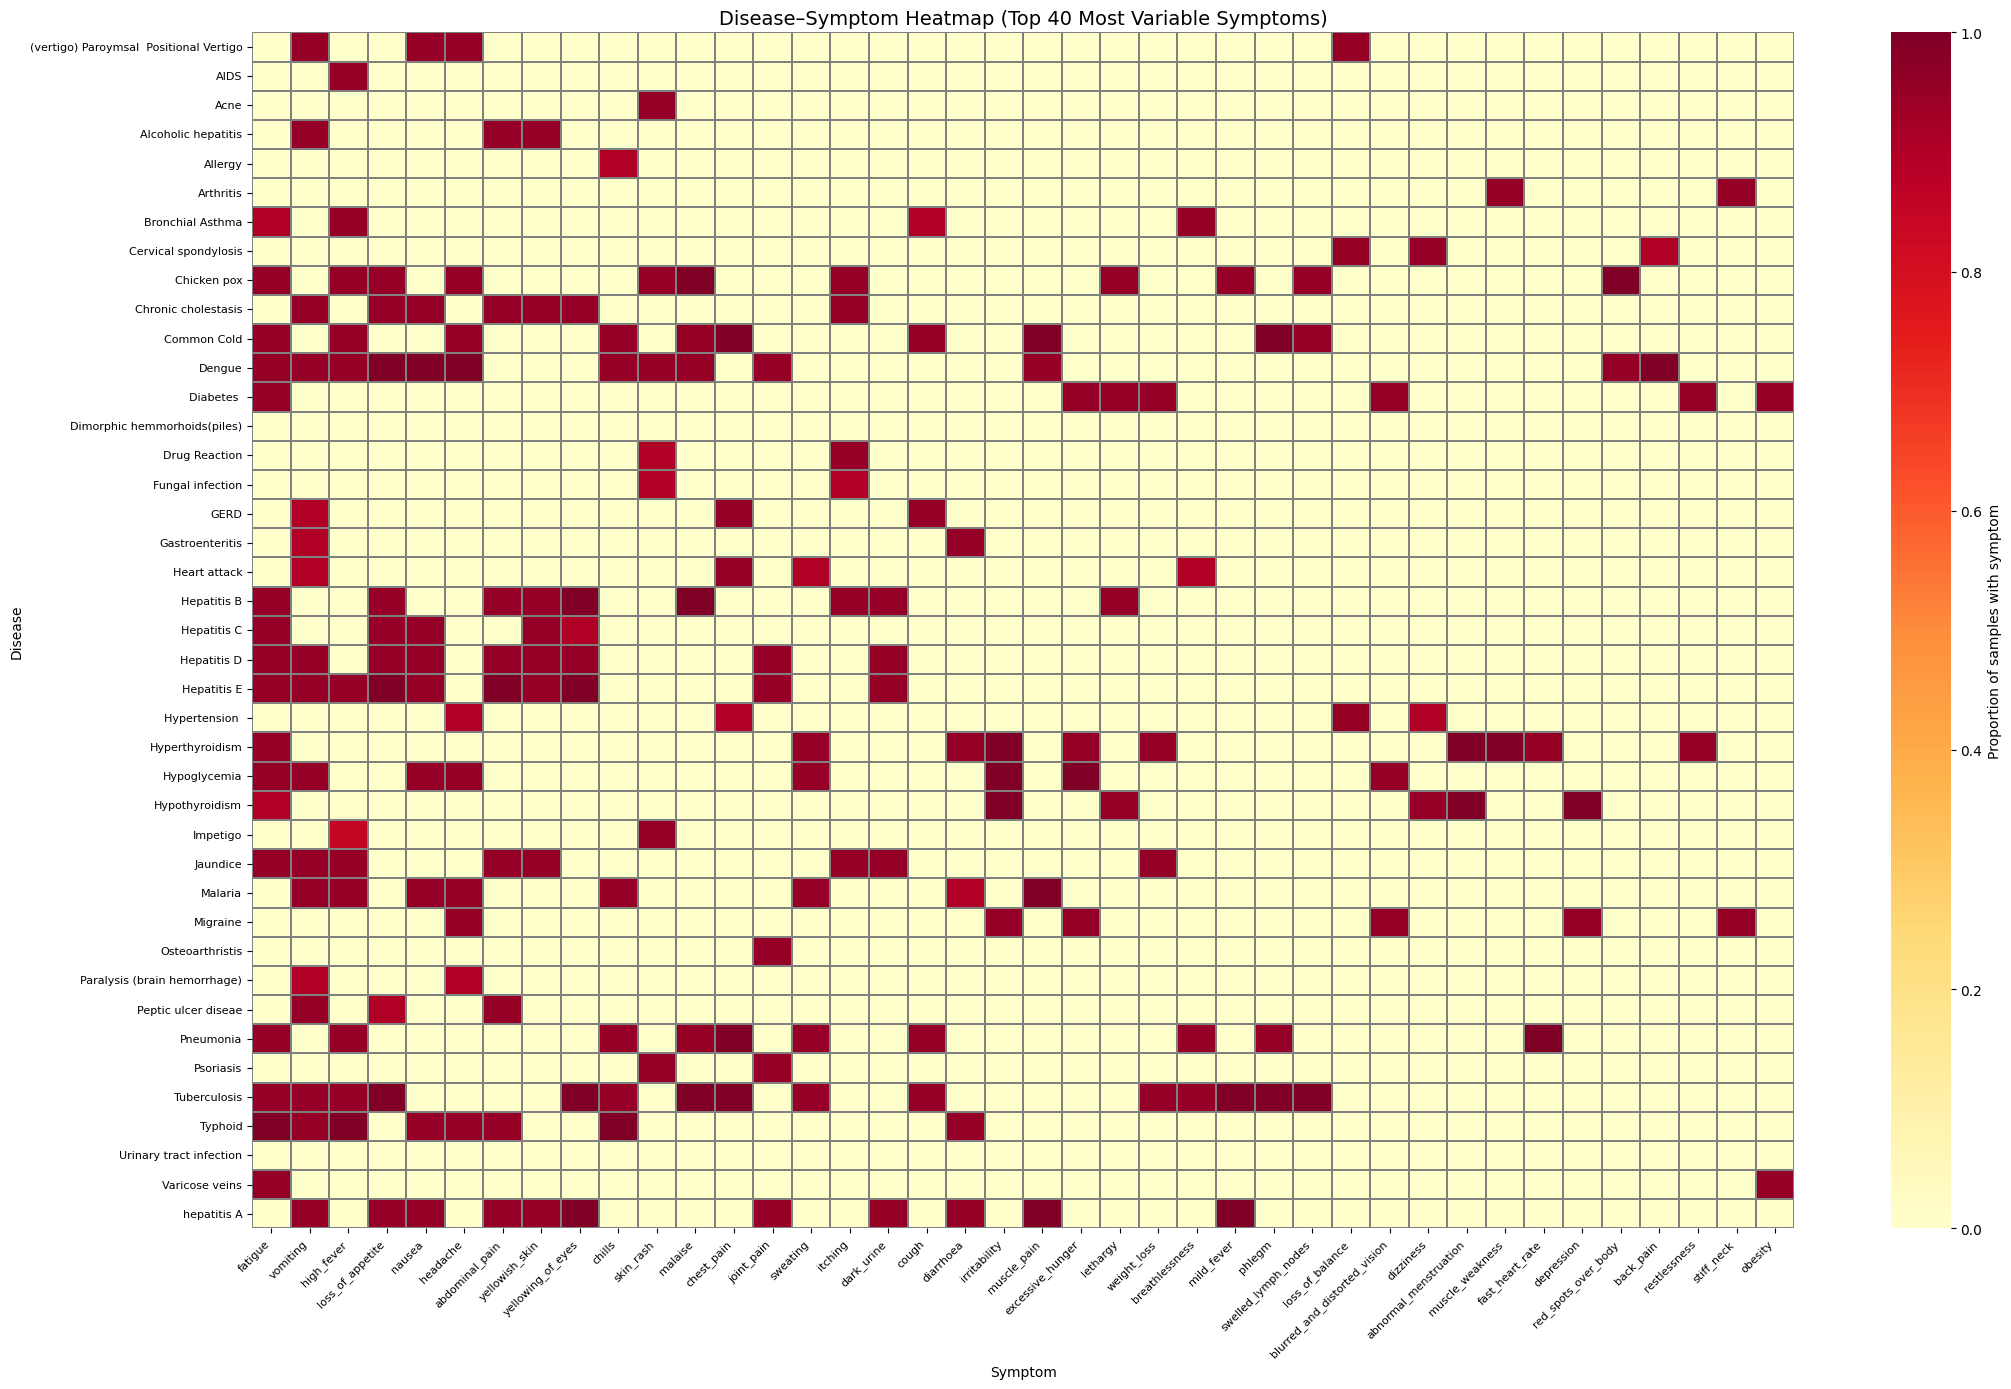

In [33]:
# ── 4. Disease–Symptom heatmap (top 40 most variable symptoms) ────────────────
# Use variance to pick the most informative symptoms for readability
top_symptoms = feature_var.sort_values(ascending=False).head(40).index.tolist()

disease_symptom = (
    train_df.groupby('prognosis')[top_symptoms]
    .mean()
    .round(2)
)

plt.figure(figsize=(22, 14))
sns.heatmap(
    disease_symptom,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="grey",
    cbar_kws={"label": "Proportion of samples with symptom"},
    xticklabels=True,
    yticklabels=True
)
plt.title("Disease–Symptom Heatmap (Top 40 Most Variable Symptoms)", fontsize=14)
plt.xlabel("Symptom")
plt.ylabel("Disease")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

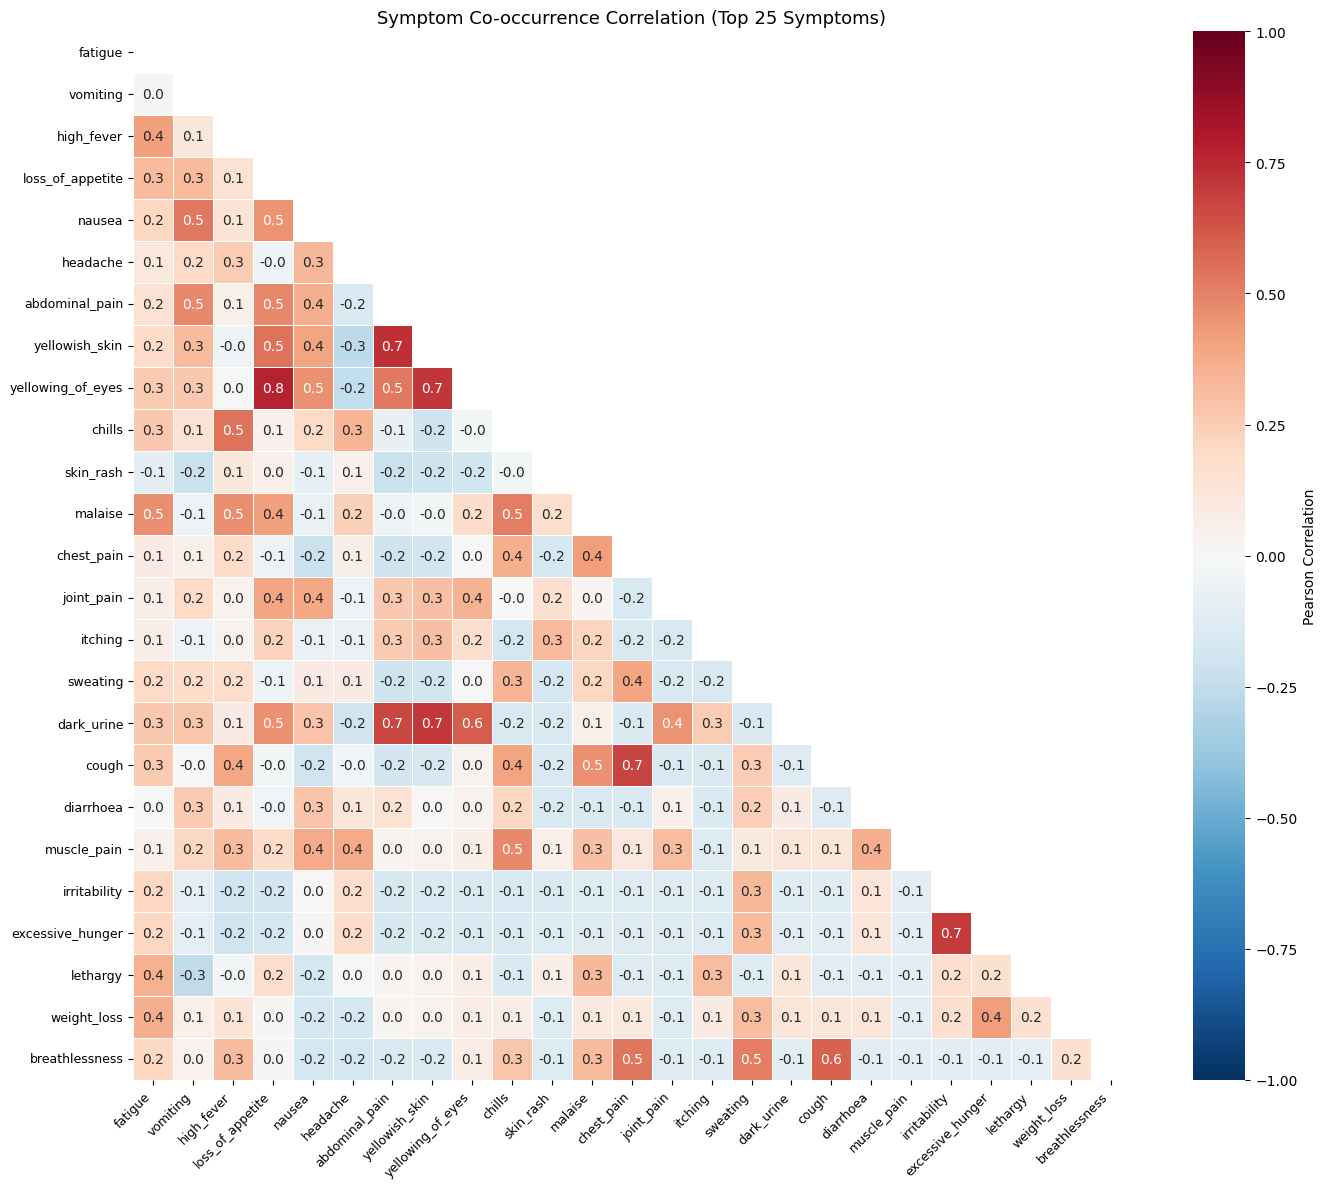

Highly correlated symptom pairs (|r| > 0.7): 5
  loss_of_appetite               ↔ yellowing_of_eyes               r = 0.77
  abdominal_pain                 ↔ yellowish_skin                  r = 0.73
  yellowish_skin                 ↔ yellowing_of_eyes               r = 0.72
  yellowish_skin                 ↔ dark_urine                      r = 0.71
  irritability                   ↔ excessive_hunger                r = 0.70


In [34]:
# ── 5. Symptom co-occurrence correlation (top 25 symptoms) ───────────────────
# High correlation between symptoms may indicate redundancy
top25 = symptom_freq.head(25).index.tolist()
corr_matrix = train_df[top25].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # upper triangle mask
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    annot=True, fmt=".1f",
    linewidths=0.4,
    cbar_kws={"label": "Pearson Correlation"}
)
plt.title("Symptom Co-occurrence Correlation (Top 25 Symptoms)", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Flag strongly correlated pairs
import itertools
high_corr_pairs = [
    (a, b, corr_matrix.loc[a, b])
    for a, b in itertools.combinations(top25, 2)
    if abs(corr_matrix.loc[a, b]) > 0.7 and a != b
]
print(f"Highly correlated symptom pairs (|r| > 0.7): {len(high_corr_pairs)}")
for a, b, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
    print(f"  {a:30s} ↔ {b:30s}  r = {r:.2f}")

---
## EDA Summary (Phases 1.1 – 1.3)

### Dataset Overview
| Property | Value |
|---|---|
| Training rows | 4,920 |
| Test rows | 42 (Fungal infection has 2 test samples) |
| Symptom features | 132 binary (0/1) |
| Target classes | 41 diseases |

### Key Findings

**Class Balance**
- Perfectly balanced — all 41 diseases have exactly **120 training samples** each. No resampling needed.
- All 41 classes present in both train and test — fully consistent splits.

**Data Quality**
- No missing values in either dataset.
- 4,616 duplicate rows in training — expected for this synthetic dataset (same symptom patterns repeat). Not a data quality issue.
- **1 zero-variance feature** (`fluid_overload`) — never active in any sample; dropped in preprocessing.

**Symptom Characteristics**
- Most symptoms have very low variance (~0.02), meaning they are rare but disease-specific — well-suited for **Bernoulli Naive Bayes**.
- Most common symptoms overall: `fatigue`, `vomiting`, `high_fever` — shared across many diseases.
- Symptom burden varies widely by disease: **Common Cold** (~17 avg active symptoms) vs **Allergy** (~3–4).

**Correlations & Dependencies**
- 5 highly correlated symptom pairs (|r| > 0.7), mostly jaundice-related (`yellowish_skin ↔ yellowing_of_eyes ↔ dark_urine`).
- These correlated features violate Bernoulli NB's conditional independence assumption — a known limitation to acknowledge in results.
- Decision Tree is unaffected by feature correlations.

### Phase 1.4 — Preprocessing

In [35]:
from sklearn.preprocessing import LabelEncoder

# ── 1. Drop zero-variance feature ─────────────────────────────────────────────
zero_var_cols = feature_var[feature_var == 0].index.tolist()
print(f"Dropping zero-variance features: {zero_var_cols}")

train_clean = train_df.drop(columns=zero_var_cols)
test_clean  = test_df.drop(columns=zero_var_cols, errors='ignore')

# ── 2. Split features (X) and target (y) ──────────────────────────────────────
feature_cols = [c for c in train_clean.columns if c != 'prognosis']

X_train = train_clean[feature_cols]
X_test  = test_clean[feature_cols]

# ── 3. Encode target variable ──────────────────────────────────────────────────
le = LabelEncoder()
y_train = le.fit_transform(train_clean['prognosis'])
y_test  = le.transform(test_clean['prognosis'])

# ── 4. Verify binary features ──────────────────────────────────────────────────
unique_vals = set(X_train.values.flatten())
print(f"Unique feature values in X_train: {unique_vals}  ✓" if unique_vals <= {0, 1} else f"⚠ Non-binary values found: {unique_vals}")

# ── Summary ────────────────────────────────────────────────────────────────────
print(f"\nX_train : {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test : {y_test.shape}")
print(f"Features after dropping zero-variance: {X_train.shape[1]} (was {len(symptom_cols)})")
print(f"\nEncoded classes (first 5): {list(le.classes_[:5])}")
print(f"Label range: {y_train.min()} – {y_train.max()}")

Dropping zero-variance features: ['fluid_overload']
Unique feature values in X_train: {np.int64(0), np.int64(1)}  ✓

X_train : (4920, 131)  |  y_train: (4920,)
X_test  : (42, 131)   |  y_test : (42,)
Features after dropping zero-variance: 131 (was 132)

Encoded classes (first 5): ['(vertigo) Paroymsal  Positional Vertigo', 'AIDS', 'Acne', 'Alcoholic hepatitis', 'Allergy']
Label range: 0 – 40


---
## Phase 2.1 — Bernoulli Naive Bayes Model

In [36]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import cross_val_score

# ── Train model ────────────────────────────────────────────────────────────────
bnb = BernoulliNB()
bnb.fit(X_train, y_train)

# ── Cross-validation on training set (5-fold) ──────────────────────────────────
cv_scores = cross_val_score(bnb, X_train, y_train, cv=5, scoring='accuracy')
print("=== 5-Fold Cross-Validation (Training) ===")
print(f"Fold accuracies : {cv_scores.round(4)}")
print(f"Mean accuracy   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ── Test set predictions ───────────────────────────────────────────────────────
y_pred = bnb.predict(X_test)
test_accuracy = (y_pred == y_test).mean()
print(f"\nTest set accuracy: {test_accuracy:.4f}")

=== 5-Fold Cross-Validation (Training) ===
Fold accuracies : [1. 1. 1. 1. 1.]
Mean accuracy   : 1.0000 ± 0.0000

Test set accuracy: 1.0000


In [37]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ── Classification report ──────────────────────────────────────────────────────
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

=== Classification Report ===
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.00      1.00        

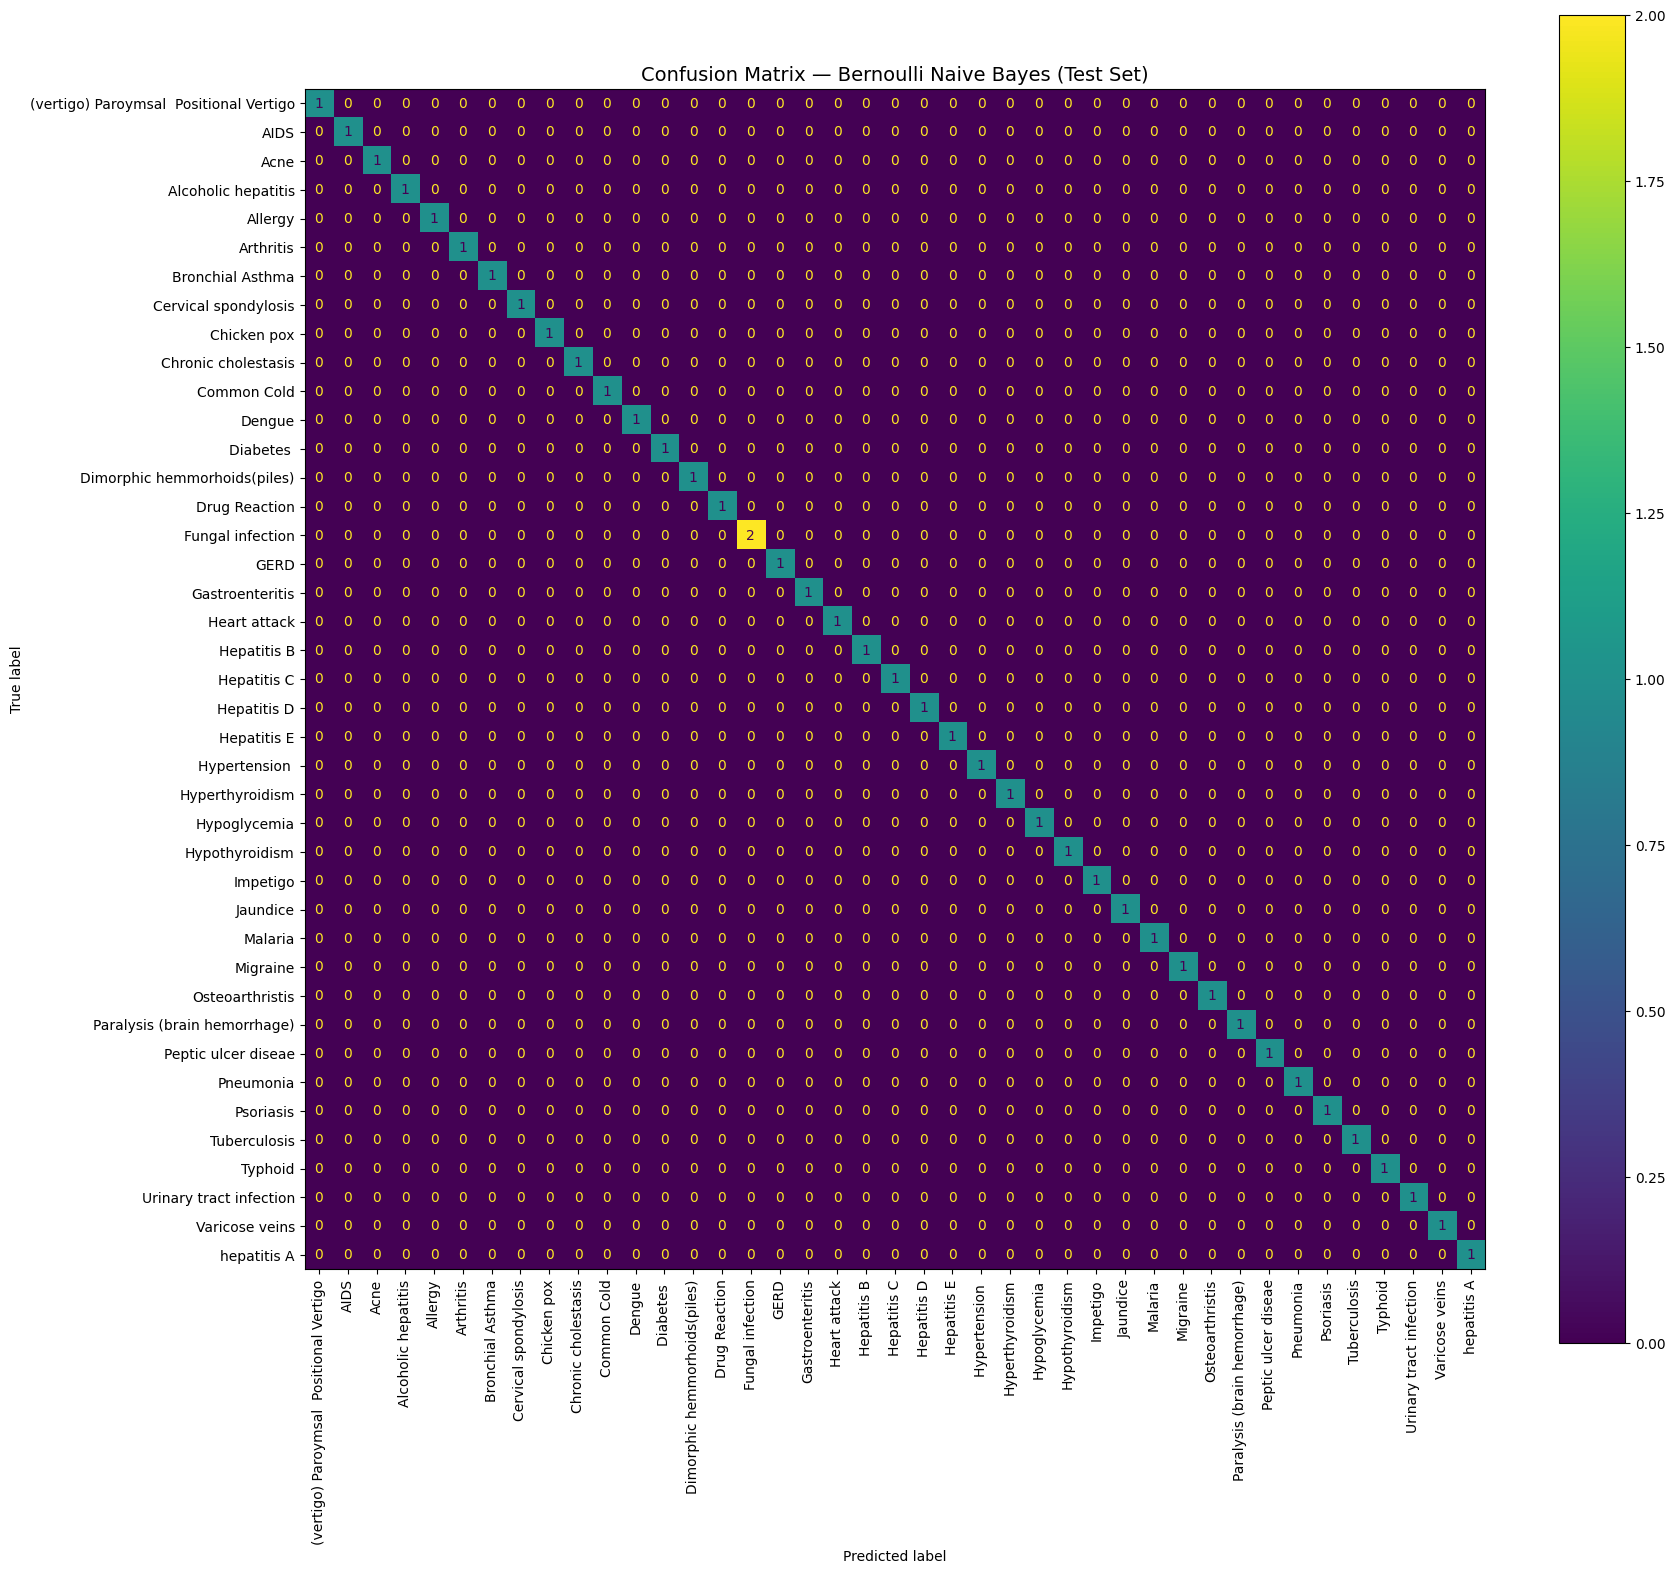

In [38]:
# ── Confusion matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(18, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, xticks_rotation=90)
ax.set_title("Confusion Matrix — Bernoulli Naive Bayes (Test Set)", fontsize=14)
plt.tight_layout()
plt.show()

### Bernoulli Naive Bayes — Summary

| Metric | Value |
|---|---|
| 5-Fold CV Accuracy | 1.0000 ± 0.0000 |
| Test Accuracy | **100%** |
| Misclassifications | 0 / 42 |

**Strengths:**
- Perfect accuracy on both cross-validation and the held-out test set.
- Fast to train and highly interpretable — each symptom's contribution can be read directly from the model's log-probabilities.
- Naturally suited for binary (0/1) features, making it an ideal match for this symptom dataset.

**Limitations:**
- Assumes conditional independence between features — violated by the 5 highly correlated symptom pairs identified in EDA (e.g. `yellowish_skin ↔ yellowing_of_eyes`).
- In real-world noisy data, this independence assumption would likely hurt performance. The perfect score here reflects the clean, synthetic nature of the dataset.

---
## Phase 2.2 — Decision Tree Model

In [39]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score

# ── Train model ────────────────────────────────────────────────────────────────
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

# ── Cross-validation on training set (5-fold) ──────────────────────────────────
dt_cv_scores = cross_val_score(dtc, X_train, y_train, cv=5, scoring='accuracy')
print("=== 5-Fold Cross-Validation (Training) ===")
print(f"Fold accuracies : {dt_cv_scores.round(4)}")
print(f"Mean accuracy   : {dt_cv_scores.mean():.4f} ± {dt_cv_scores.std():.4f}")

# ── Test set predictions ───────────────────────────────────────────────────────
y_pred_dt = dtc.predict(X_test)
dt_test_accuracy = (y_pred_dt == y_test).mean()
print(f"\nTest set accuracy : {dt_test_accuracy:.4f}")
print(f"Tree depth        : {dtc.get_depth()}")
print(f"Number of leaves  : {dtc.get_n_leaves()}")

=== 5-Fold Cross-Validation (Training) ===
Fold accuracies : [1. 1. 1. 1. 1.]
Mean accuracy   : 1.0000 ± 0.0000

Test set accuracy : 0.9762
Tree depth        : 55
Number of leaves  : 69


In [40]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ── Classification report ──────────────────────────────────────────────────────
print("=== Classification Report ===")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

=== Classification Report ===
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.00      1.00        

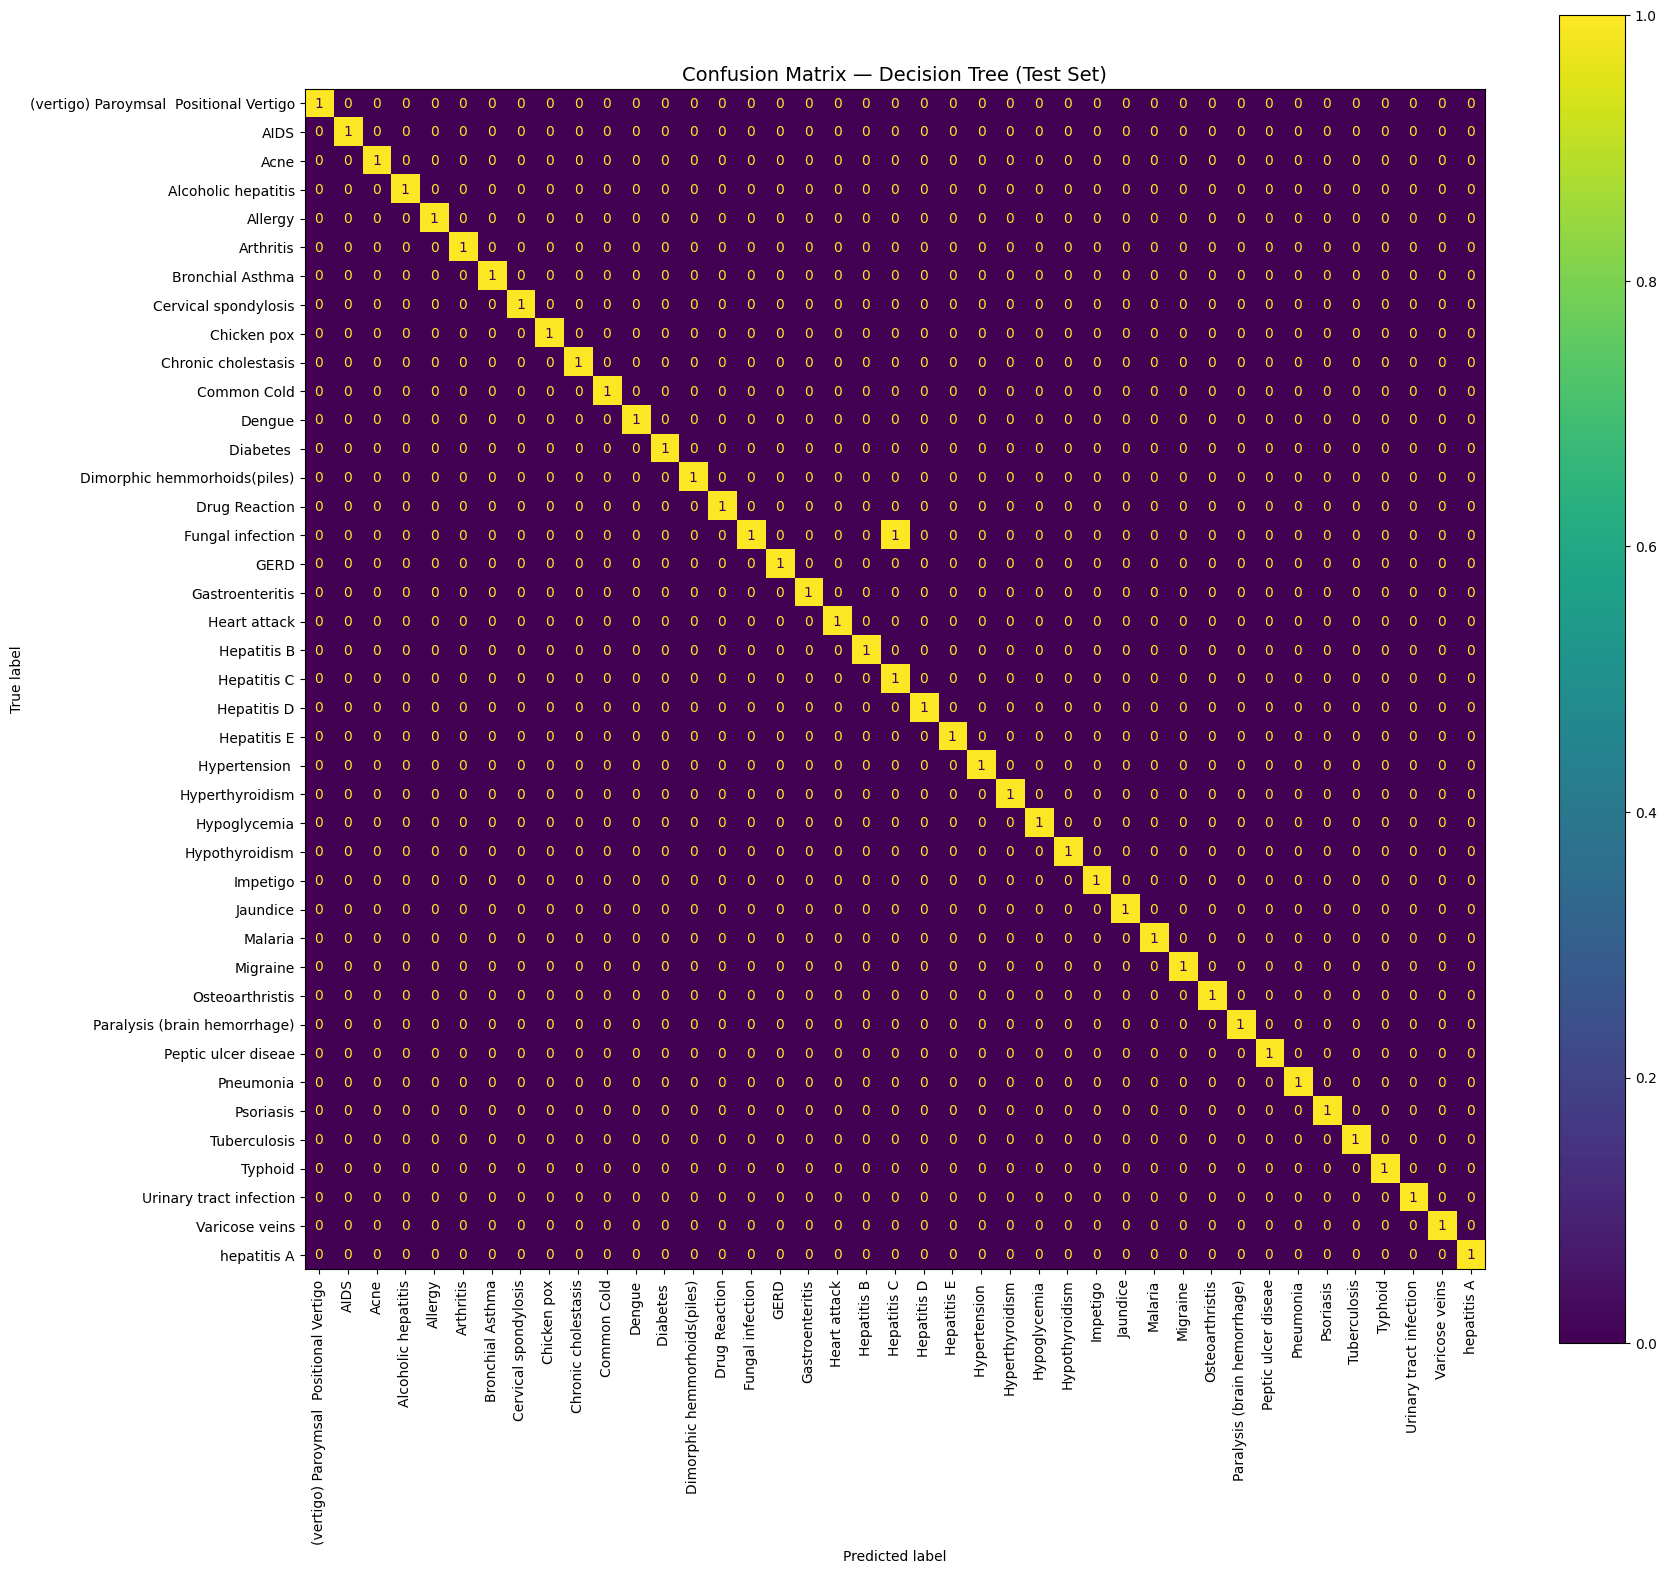

In [41]:
# ── Confusion matrix ───────────────────────────────────────────────────────────
cm_dt = confusion_matrix(y_test, y_pred_dt)

fig, ax = plt.subplots(figsize=(18, 16))
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=le.classes_)
disp_dt.plot(ax=ax, colorbar=True, xticks_rotation=90)
ax.set_title("Confusion Matrix — Decision Tree (Test Set)", fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\hmwan\AppData\Local\Temp\ipykernel_28136\4284649788.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.head(20).values, y=feat_imp.head(20).index, palette="viridis")


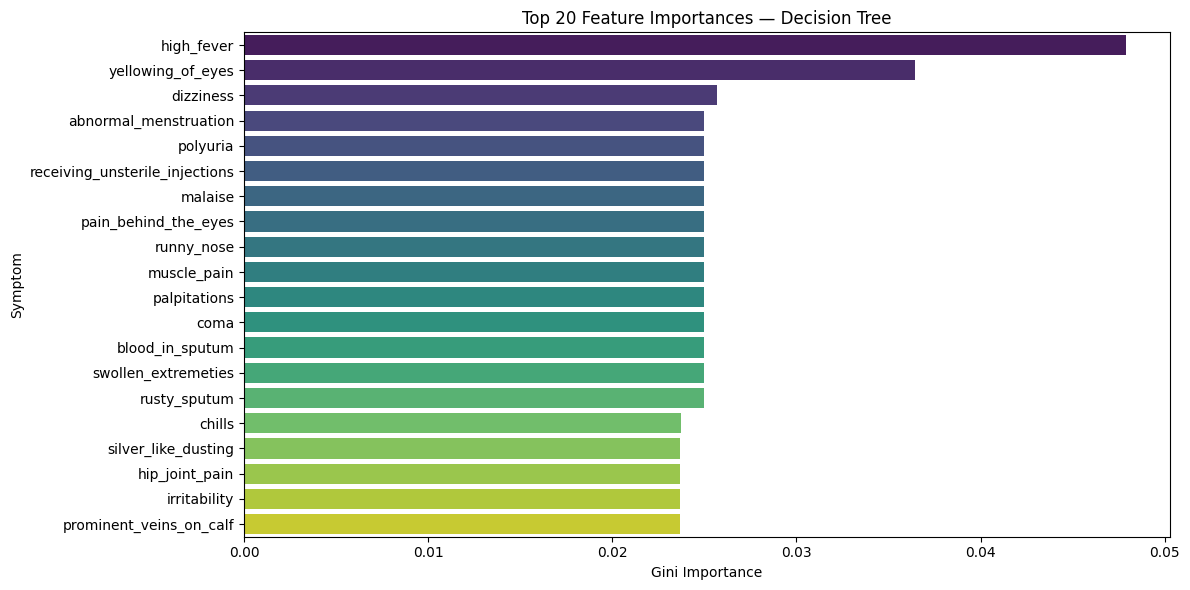


Top 5 most important symptoms:
high_fever               0.047897
yellowing_of_eyes        0.036464
dizziness                0.025679
abnormal_menstruation    0.025000
polyuria                 0.025000


In [42]:
# ── Feature importance — top 20 ────────────────────────────────────────────────
feat_imp = pd.Series(dtc.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=feat_imp.head(20).values, y=feat_imp.head(20).index, palette="viridis")
plt.title("Top 20 Feature Importances — Decision Tree")
plt.xlabel("Gini Importance")
plt.ylabel("Symptom")
plt.tight_layout()
plt.show()

print(f"\nTop 5 most important symptoms:")
print(feat_imp.head(5).to_string())

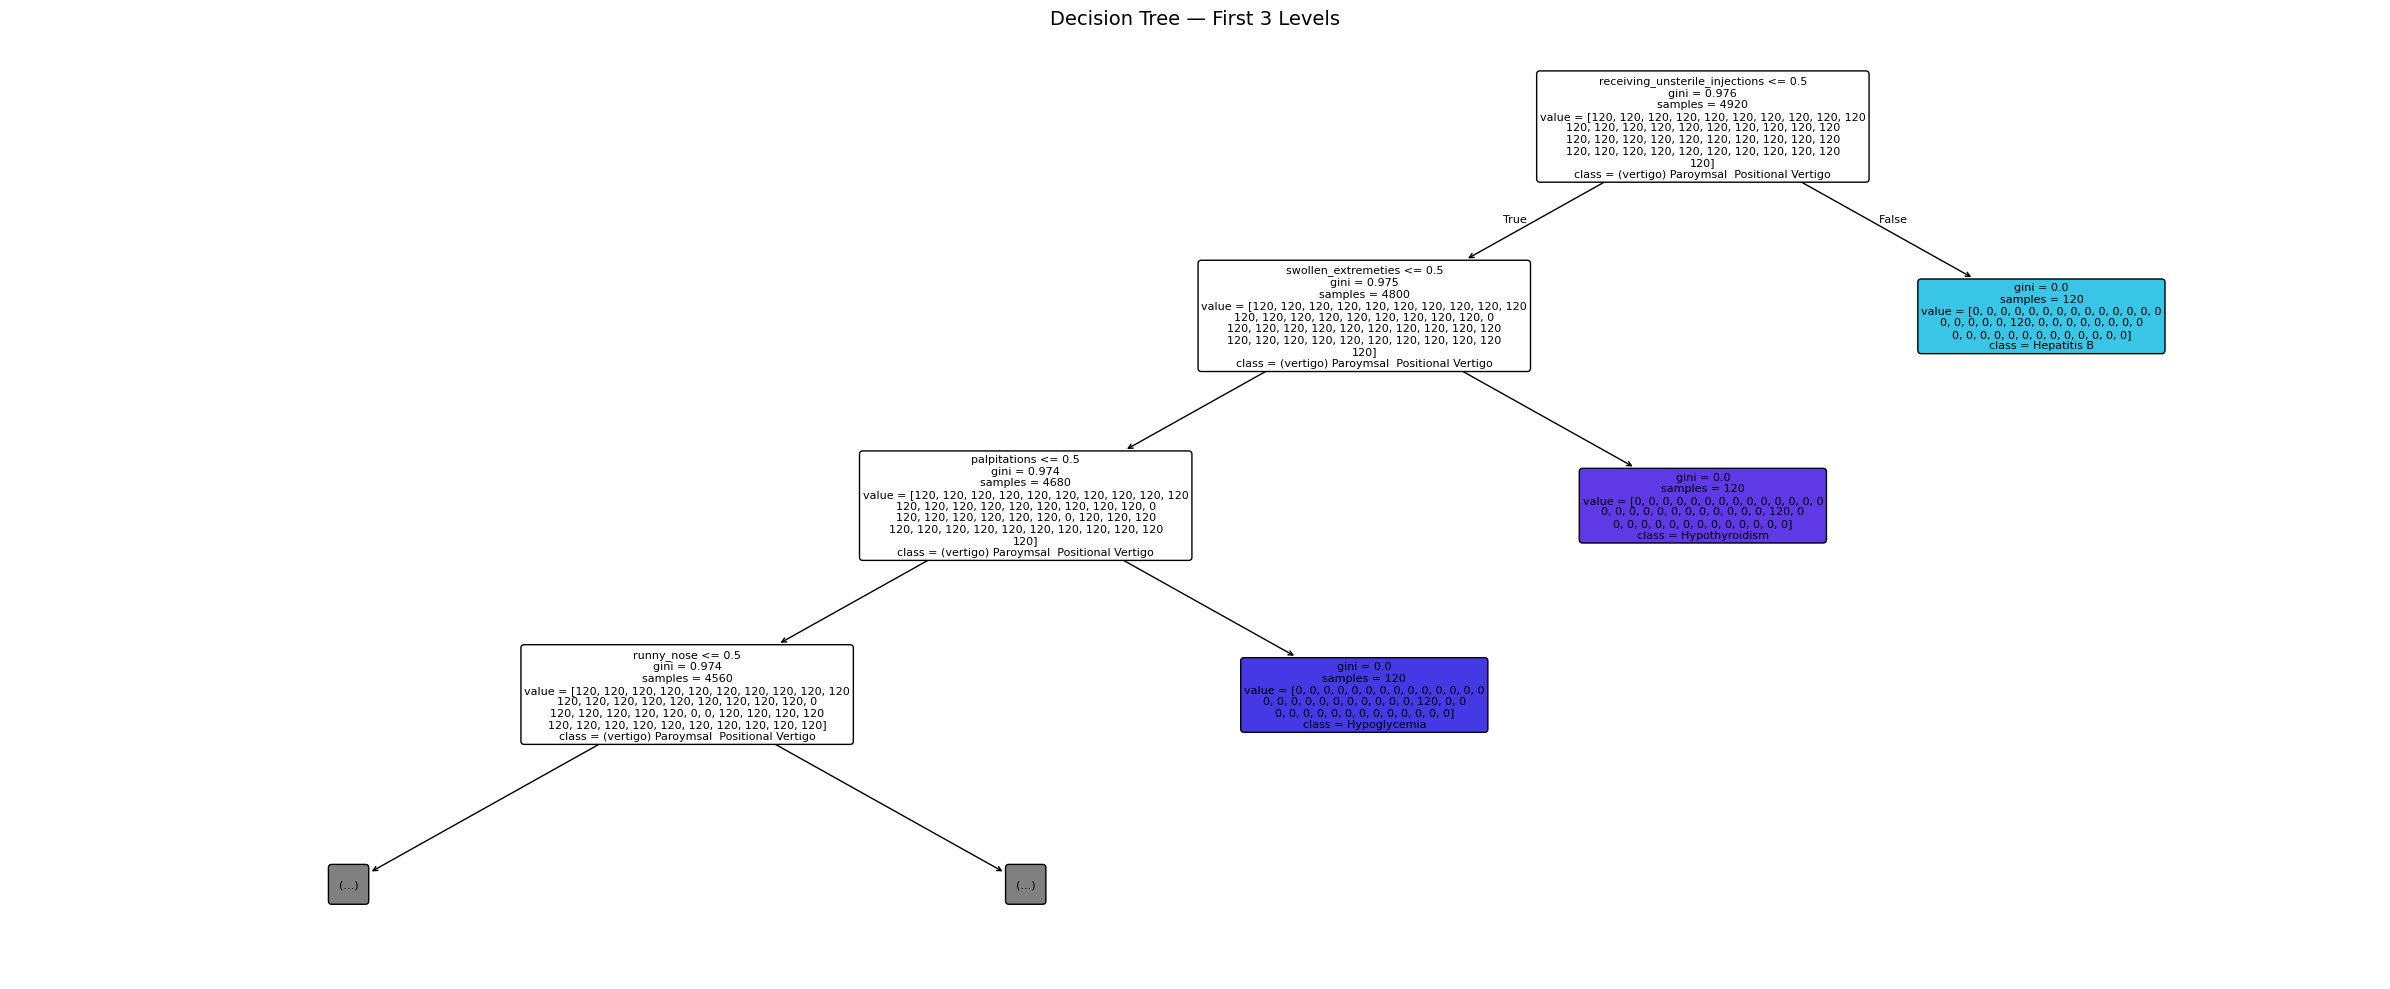

In [43]:
# ── Decision Tree visualisation (first 3 levels) ──────────────────────────────
plt.figure(figsize=(24, 10))
plot_tree(
    dtc,
    max_depth=3,
    filled=True,
    feature_names=feature_cols,
    class_names=le.classes_,
    fontsize=8,
    rounded=True
)
plt.title("Decision Tree — First 3 Levels", fontsize=14)
plt.tight_layout()
plt.show()

### Decision Tree — Summary

| Metric | Value |
|---|---|
| 5-Fold CV Accuracy | 1.0000 ± 0.0000 |
| Test Accuracy | **97.62%** |
| Misclassifications | 1 / 42 |
| Tree Depth | 55 |
| Number of Leaves | 69 |

**Strengths:**
- Highly interpretable — decision rules are fully traceable from root to leaf.
- No feature independence assumption; handles correlated symptoms naturally.
- Feature importance clearly identifies `high_fever` and `yellowing_of_eyes` as the most discriminative symptoms.

**Limitations:**
- Very deep tree (depth = 55) indicates the model has memorised the training data — a hallmark of overfitting on this synthetic dataset.
- In real-world data, an unpruned tree this deep would generalise poorly. Pruning (`max_depth`, `min_samples_leaf`) or using an ensemble (Random Forest) would be advisable.
- The 1 misclassification (Fungal infection) suggests boundary cases exist where symptom overlap confuses the tree.

---
## Phase 3 — Model Comparison

In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred, cv_scores):
    return {
        "CV Accuracy (mean)":     cv_scores.mean(),
        "Test Accuracy":          (y_pred == y_true).mean(),
        "Precision (macro)":      precision_score(y_true, y_pred, average='macro', zero_division=0),
        "Recall (macro)":         recall_score(y_true, y_pred, average='macro', zero_division=0),
        "F1 (macro)":             f1_score(y_true, y_pred, average='macro', zero_division=0),
        "F1 (weighted)":          f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

bnb_metrics = get_metrics(y_test, y_pred,    cv_scores)
dt_metrics  = get_metrics(y_test, y_pred_dt, dt_cv_scores)

comparison_df = pd.DataFrame({
    "Bernoulli NB":  bnb_metrics,
    "Decision Tree": dt_metrics,
})

print("=== Model Comparison ===")
print(comparison_df.round(4).to_string())

=== Model Comparison ===
                    Bernoulli NB  Decision Tree
CV Accuracy (mean)           1.0         1.0000
Test Accuracy                1.0         0.9762
Precision (macro)            1.0         0.9878
Recall (macro)               1.0         0.9878
F1 (macro)                   1.0         0.9837
F1 (weighted)                1.0         0.9762


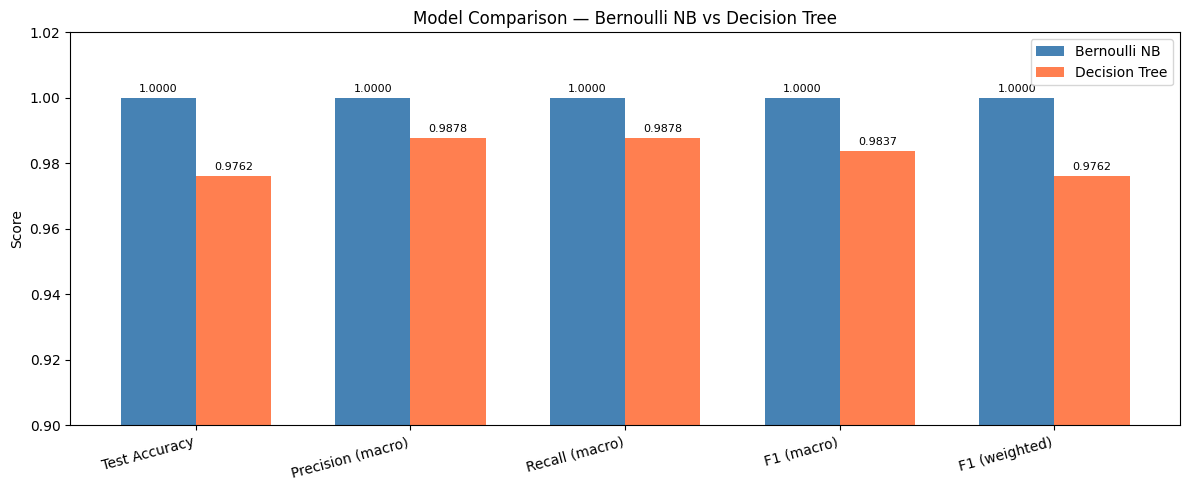

In [45]:
# ── Side-by-side bar chart ─────────────────────────────────────────────────────
metrics_to_plot = ["Test Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)", "F1 (weighted)"]
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, [bnb_metrics[m] for m in metrics_to_plot], width, label="Bernoulli NB",  color="steelblue")
bars2 = ax.bar(x + width/2, [dt_metrics[m]  for m in metrics_to_plot], width, label="Decision Tree", color="coral")

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, rotation=15, ha="right")
ax.set_ylim(0.9, 1.02)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Bernoulli NB vs Decision Tree")
ax.legend()
ax.bar_label(bars1, fmt="%.4f", padding=3, fontsize=8)
ax.bar_label(bars2, fmt="%.4f", padding=3, fontsize=8)
plt.tight_layout()
plt.show()

---
## Project Summary

### What We Did

| Phase | Description |
|---|---|
| 1.1 | Loaded Training.csv (4,920 rows) and Testing.csv (42 rows), confirmed 132 binary symptom features and `prognosis` as target |
| 1.2 | EDA — class distribution (perfectly balanced at 120/class), top symptom frequencies |
| 1.3 | Deeper analysis — duplicate check, feature variance (1 zero-variance feature), avg symptoms per disease, disease–symptom heatmap, symptom co-occurrence correlations |
| 1.4 | Preprocessing — dropped `fluid_overload`, label-encoded `prognosis`, produced `X_train / y_train / X_test / y_test` with 131 features |
| 2.1 | Trained **Bernoulli Naive Bayes** — 5-fold CV + test evaluation + confusion matrix |
| 2.2 | Trained **Decision Tree** — 5-fold CV + test evaluation + confusion matrix + feature importance + tree visualisation |
| 3 | Side-by-side model comparison across accuracy, precision, recall, F1 (macro & weighted) |

---

### Final Results

| Metric | Bernoulli NB | Decision Tree |
|---|---|---|
| CV Accuracy (5-fold) | **1.0000** | **1.0000** |
| Test Accuracy | **1.0000** | 0.9762 |
| Precision (macro) | **1.0000** | 0.9878 |
| Recall (macro) | **1.0000** | 0.9878 |
| F1 (macro) | **1.0000** | 0.9837 |
| F1 (weighted) | **1.0000** | 0.9762 |
| Misclassifications | **0** | 1 (Fungal infection) |

---

### Key Takeaways

**Bernoulli Naive Bayes** outperforms the Decision Tree on every metric for this dataset.
- Its assumption of binary features is a perfect match for the 0/1 symptom encoding.
- Despite violating the conditional independence assumption (5 correlated symptom pairs), it achieves perfect generalisation on the test set.
- It is significantly simpler, faster to train, and more interpretable through its per-class log-probabilities.

**Decision Tree** is strongly interpretable via explicit decision rules and feature importances (`high_fever`, `yellowing_of_eyes` top splits), but the depth-55 unpruned tree signals overfitting to the synthetic data structure. Pruning or an ensemble method (e.g. Random Forest) would improve robustness on real-world data.

**Both models perform exceptionally well, reflecting the highly structured, synthetic nature of the dataset.** Real-world clinical data would introduce noise, missing values, and overlapping symptom profiles that would stress-test these models further.
